In [10]:
import pandas as pd
import geopandas as gpd


df = pd.read_csv(r"data/result1/cities_minute_counts.csv")

df["create_time"] = pd.to_datetime(df["create_time"])

gdf = gpd.read_file(r"data/result2/cities.shp")


In [11]:
import pandas as pd
import numpy as np
import geopandas as gpd
import datetime

time_mask = (df['create_time'].dt.time >= datetime.time(21, 0, 0)) | (df['create_time'].dt.time < datetime.time(4, 0, 0))

intensity = df[time_mask].groupby('city')['post_count'].sum().reset_index(name='intensity')

def calc_npi(group):
    ts = group.groupby('time_bin')['post_count'].sum()
    if ts.empty:
        return np.nan
    
    ts_sorted = ts.sort_index().reindex(range(0, int(ts.index.max()) + 1), fill_value=0)
    S = ts_sorted.cumsum().astype(float)
    S_total = S.iloc[-1]
    
    if S_total == 0:
        return np.nan
        
    one_minus_f = 1 - (S / S_total)
    mask_50 = one_minus_f <= 0.5
    
    if mask_50.any():
        return mask_50.idxmax()
    return np.nan

df_sub = df[time_mask].copy()

df_sub['time_bin'] = df_sub['create_time'].apply(
    lambda dt: (dt.hour - 21) * 60 + dt.minute if dt.hour >= 21 else 180 + dt.hour * 60 + dt.minute
)

city_time_df = df_sub.groupby('city').apply(calc_npi).reset_index(name='time')

time_intensity_df = gdf[['city']].copy()
time_intensity_df = pd.merge(time_intensity_df, city_time_df, how='left', on='city')
time_intensity_df = pd.merge(time_intensity_df, intensity, how='left', on='city')

time_intensity_df

,city,time,intensity
0,梅州,132,13170
1,吕梁,120,17040
2,舟山,102,31566
3,朝阳,101,7912
4,广安,119,6443
...,...,...,...
271,陇南,111,7059
272,保山,119,11598
273,遂宁,117,7474
274,合肥,117,167171


In [12]:
data = pd.read_csv(r'data/result2/city_avg_embeddings.csv')

city_list = time_intensity_df['city'].unique().tolist()

city_embedding = data[data['city'].isin(city_list)].copy()
city_embedding

,city,embeddings
1,三亚,"-0.020466291859151255,0.05003875978776092,-0.0..."
2,三明,"-0.018095528107093212,0.04265825861554369,-0.0..."
4,三门峡,"-0.016680641634988953,0.04114852565564198,-0.0..."
5,上海,"-0.014896160186663667,0.040993469554816926,-0...."
6,上饶,"-0.018663554122222602,0.044095402475602424,-0...."
...,...,...
342,黔东南,"-0.01684232140224307,0.04056976486606181,-0.01..."
343,黔南,"-0.01552172210969697,0.041059987113443934,-0.0..."
344,黔西南,"-0.016256719121797616,0.04024292790711973,-0.0..."
345,齐齐哈尔,"-0.01707788482087492,0.041336054277236155,-0.0..."


In [13]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import umap
from ast import literal_eval
from sklearn.preprocessing import StandardScaler


cities = city_embedding['city'].values
city_embedding['embeddings'] = city_embedding['embeddings'].apply(literal_eval)


X = np.array(city_embedding['embeddings'].tolist())
scaler  = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

pca = PCA(n_components=0.95).fit(X_scaled)
X_pca = pca.transform(X_scaled)
print(f"Proportion of retained variance: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"D：{X_pca.shape}")


umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=42
).fit(X_pca)
emb_umap = umap_model.transform(X_pca)  # shape = (n_cities, 2)

umap_df = pd.DataFrame({
    'city': cities,
    'umap_1': emb_umap[:, 0],
    'umap_2': emb_umap[:, 1],
})


time_intensity_df = pd.merge(
    time_intensity_df,
    umap_df,
    on='city',
    how='left'
)

time_intensity_df

Proportion of retained variance: 0.9509
D：(276, 87)


d:\Anaconda\envs\LLM\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\Anaconda\envs\LLM\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\Anaconda\envs\LLM\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,city,time,intensity,umap_1,umap_2
0,梅州,132,13170,3.175452,6.958565
1,吕梁,120,17040,2.973684,3.357782
2,舟山,102,31566,5.663746,-0.090759
3,朝阳,101,7912,2.659808,1.873272
4,广安,119,6443,3.196313,6.344944
...,...,...,...,...,...
271,陇南,111,7059,4.239348,5.974148
272,保山,119,11598,6.201652,4.471026
273,遂宁,117,7474,1.444519,3.866109
274,合肥,117,167171,2.367577,6.124521


In [14]:
import statsmodels.api as sm

X = time_intensity_df[['umap_1', 'umap_2']]
y = time_intensity_df['time']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   time   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     4.059
Date:                Fri, 03 Apr 2026   Prob (F-statistic):             0.0183
Time:                        22:22:21   Log-Likelihood:                -1084.9
No. Observations:                 276   AIC:                             2176.
Df Residuals:                     273   BIC:                             2187.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        110.4655      2.866     38.546      0.0

                            OLS Regression Results                            
Dep. Variable:          log_intensity   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     15.44
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           0.000108
Time:                        22:22:27   Log-Likelihood:                -184.19
No. Observations:                 276   AIC:                             372.4
Df Residuals:                     274   BIC:                             379.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3220      0.271     12.260      0.0

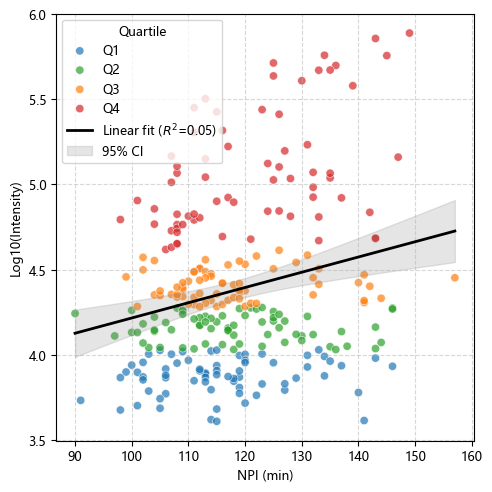

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from adjustText import adjust_text


plt.rcParams.update({
    'font.size': 9,
    'font.family': 'Microsoft YaHei'
})

time_intensity_df['log_intensity'] = np.log10(time_intensity_df['intensity'])

quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
time_intensity_df['quartile'] = pd.qcut(
    time_intensity_df['log_intensity'],
    q=4,
    labels=quartile_labels
)

palette = {
    'Q1': '#1f77b4',
    'Q2': '#2ca02c',
    'Q3': '#ff7f0e',
    'Q4': '#d62728'
}

time_intensity_df['color'] = time_intensity_df['quartile'].map(palette)


y = time_intensity_df['log_intensity']
X = time_intensity_df['time']
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())
r2 = model.rsquared

x_pred = np.linspace(X.min(), X.max(), 100)
x_pred_sm = sm.add_constant(x_pred)
pred = model.get_prediction(x_pred_sm)
pred_mean = pred.predicted_mean
ci_lower, ci_upper = pred.conf_int(alpha=0.05).T


plt.figure(figsize=(5, 5))


for q in quartile_labels:
    subset = time_intensity_df[time_intensity_df['quartile'] == q]
    plt.scatter(
        
        subset['time'],
        subset['log_intensity'],
        c=subset['color'],
        label=q,
        edgecolors='w', linewidths=0.5, alpha=0.7
    )


plt.plot(
    x_pred, pred_mean,
    color='black', linewidth=2,
    label=f'Linear fit ($R^2$={r2:.2f})'
)


plt.fill_between(
    x_pred, ci_lower, ci_upper,
    color='gray', alpha=0.2,
    label='95% CI'
)


plt.ylabel('Log10(Intensity)')
plt.xlabel('NPI (min)')
plt.legend(title='Quartile', frameon=True, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# plt.savefig(r'plot/jieou/ols.jpg', dpi=300)  # 保存为PNG格式

plt.show()


C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_24016\1413940013.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_24016\1413940013.py:117: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_val = float(match['p-adj'])


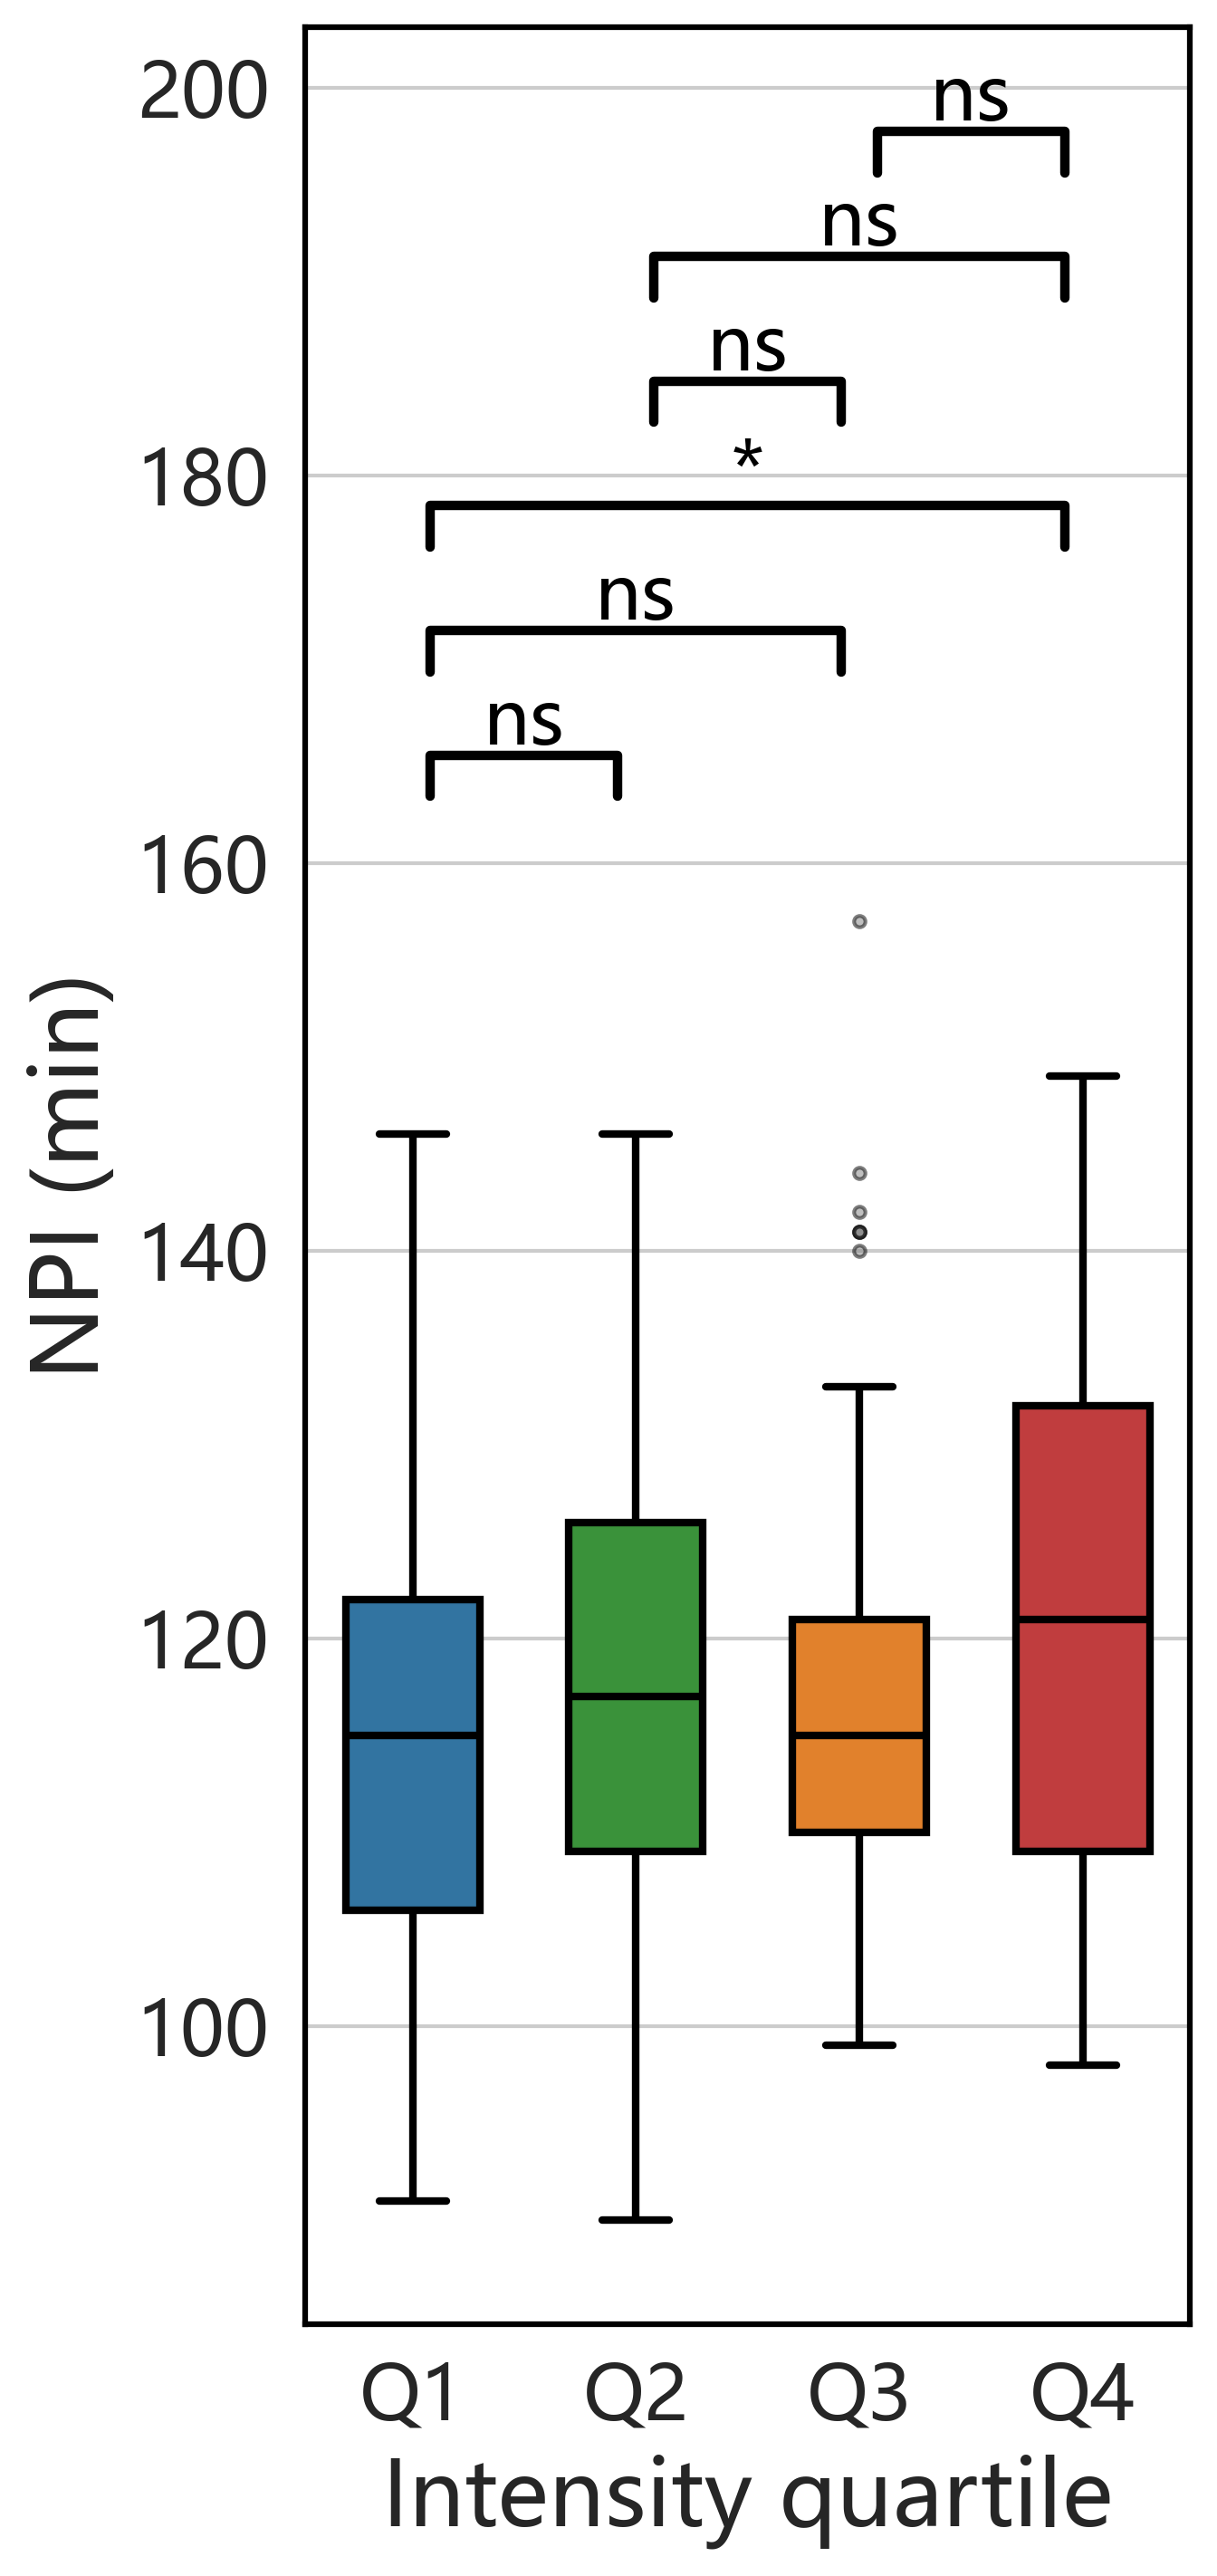

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd


plt.rcParams.update({
    'font.size': 30,
    'font.family': 'Microsoft YaHei'
})

sns.set_theme(style="whitegrid")

sns.set_theme(
    context='notebook',
    style="whitegrid",
    font='Microsoft YaHei',
    rc={
        'font.size': 24,
        'axes.titlesize': 24,
        'axes.labelsize': 24,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
    }
)


quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
palette = {
    'Q1': '#1f77b4', 
    'Q2': '#2ca02c', 
    'Q3': '#ff7f0e',
    'Q4': '#d62728' 
}

quartile_cat = pd.CategoricalDtype(categories=quartile_labels, ordered=True)
time_intensity_df['quartile'] = time_intensity_df['quartile'].astype(quartile_cat)

fig, ax = plt.subplots(figsize=(5, 10), dpi=300)

sns.boxplot(
    x='quartile',
    y='time',
    data=time_intensity_df,
    order=quartile_labels,
    palette=palette,
    width=0.6,
    ax=ax,
    linewidth=2,
    boxprops={'edgecolor': 'black'},
    whiskerprops={'color': 'black', 'linewidth': 2},
    capprops={'color': 'black', 'linewidth': 2},
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': 'gray', 'alpha': 0.5, 'markeredgecolor': 'black'}
)

ax.set_xlabel('Intensity quartile')
ax.set_ylabel('NPI (min)')
ax.set_title('')


from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import f_oneway
import matplotlib.patches as mpatches

groups = [
    time_intensity_df.loc[time_intensity_df['quartile'] == q, 'time']
    for q in quartile_labels
]
F_anova, p_anova = f_oneway(*groups)



pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]


tukey_result = pairwise_tukeyhsd(
    endog=time_intensity_df['time'],
    groups=time_intensity_df['quartile'],
    alpha=0.05
)

tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])


max_y = time_intensity_df['time'].max()
min_y = time_intensity_df['time'].min()
step = (max_y - min_y) * 0.08

significance_map = {3: '***', 2: '**', 1: '*', 0: 'ns'}
def significance_label(p):
    if p < 0.001:
        return significance_map[3]
    elif p < 0.01:
        return significance_map[2]
    elif p < 0.05:
        return significance_map[1]
    return significance_map[0]

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

for k, (i, j) in enumerate(pairs):
    group1 = quartile_labels[i]
    group2 = quartile_labels[j]

    match = tukey_df[
        ((tukey_df['group1'] == group1) & (tukey_df['group2'] == group2)) |
        ((tukey_df['group1'] == group2) & (tukey_df['group2'] == group1))
    ]
    if match.empty:
        continue

    p_val = float(match['p-adj'])

    base_y = max_y + step * (k + 1) * 1.2
    line_y = base_y + step * 0.4
    text_y = line_y + step * 0.2

    x1, x2 = i, j

    ax.plot([x1 + 0.08, x1 + 0.08, x2 - 0.08, x2 - 0.08],
            [base_y, line_y, line_y, base_y],
            lw=2.5, color='black')

    ax.text((x1 + x2) / 2, text_y - 1.5, significance_label(p_val),
                        ha='center', va='bottom', color='black', fontsize=20)


plt.tight_layout()
# plt.savefig(r'plot/jieou/boxplot.jpg', dpi=300)
plt.show()

In [17]:
import pandas as pd
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

df = time_intensity_df.copy()

df['time_q'] = pd.qcut(df['time'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
summary = (df.groupby('time_q')['intensity']
             .agg(['count', 'mean', 'std'])
             .rename(columns={'count': 'n', 'mean': 'mean_int', 'std': 'std_int'}))
print('组内描述性统计：\n', summary, '\n')
pairs      = list(combinations(['Q1', 'Q2', 'Q3', 'Q4'], 2))
t_stats    = []
p_values   = []

for g1, g2 in pairs:
    i1 = df.loc[df['time_q'] == g1, 'intensity']
    i2 = df.loc[df['time_q'] == g2, 'intensity']
    t, p = ttest_ind(i1, i2, equal_var=False)
    t_stats.append(t)
    p_values.append(p)

rej, p_bonf, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

results = pd.DataFrame({
    'Group 1': [f'{g1}' for g1, _ in pairs],
    'Group 2': [f'{g2}' for _, g2 in pairs],
    't‑stat':  [round(t, 4) for t in t_stats],
    'p‑value': [f'{p:.4g}' for p in p_values],
    'p‑value (Bonf)': [f'{pb:.4g}' for pb in p_bonf],
    'Significant (α=0.05)': rej
})

print('两两 Welch t 检验结果（含 Bonferroni 校正）：\n')
print(results.to_string(index=False))


组内描述性统计：
          n       mean_int        std_int
time_q                                  
Q1      75   28623.226667   29349.924813
Q2      66   42881.136364   67069.829934
Q3      67   48848.268657   91660.517919
Q4      68  104047.588235  181782.998914 

两两 Welch t 检验结果（含 Bonferroni 校正）：

Group 1 Group 2  t‑stat  p‑value p‑value (Bonf)  Significant (α=0.05)
     Q1      Q2 -1.5977   0.1138         0.6826                 False
     Q1      Q3 -1.7287  0.08782         0.5269                 False
     Q1      Q4 -3.3817 0.001181       0.007084                  True
     Q2      Q3 -0.4289   0.6688              1                 False
     Q2      Q4 -2.5984  0.01103        0.06618                 False
     Q3      Q4 -2.2325  0.02783          0.167                 False


C:\Users\Ke Entong\AppData\Local\Temp\ipykernel_24016\4179461080.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (df.groupby('time_q')['intensity']


In [ ]:
from googletrans import Translator
import pandas as pd

translator = Translator()

time_intensity_df['city_en'] = time_intensity_df['city'].apply(lambda x: translator.translate(x, src='zh-cn', dest='en').text)
time_intensity_df


,city,intensity,umap_1,umap_2,half_life_minutes,city_en
0,梅州,13170,7.036358,-3.045211,132,Meizhou
1,吕梁,17040,8.458356,1.528544,120,Lu Liang
2,舟山,31566,13.575398,5.043075,102,Zhoushan
3,朝阳,7912,9.173719,3.694468,101,Chaoyang
4,广安,6443,8.391058,-2.203086,119,Guang'an
...,...,...,...,...,...,...
271,陇南,7059,9.628973,-1.643469,111,Longnan
272,保山,11598,11.690678,-1.089342,119,Baoshan
273,遂宁,7474,6.561677,0.327753,117,Suining
274,合肥,167171,7.773046,-2.045031,117,Hefei


In [ ]:
time_intensity_df.to_csv(r'data/result2/data_手动修正.csv', encoding='utf-8-sig')

I manually adjusted the translated names of the cities here

In [9]:
import pandas as pd

time_intensity_df = pd.read_csv(r'data/result2/data_手动修正.csv',index_col='Unnamed: 0')
time_intensity_df

,city,intensity,umap_1,umap_2,time,log_intensity,quartile,color,city_en
0,梅州,13170,3.175451,6.958565,132,4.119586,Q2,#2ca02c,Meizhou
1,吕梁,17040,2.973684,3.357782,120,4.231470,Q2,#2ca02c,Luliang
2,舟山,31566,5.663746,-0.090759,102,4.499220,Q3,#ff7f0e,Zhoushan
3,朝阳,7912,2.659808,1.873272,101,3.898286,Q1,#1f77b4,Chaoyang
4,广安,6443,3.196313,6.344944,119,3.809088,Q1,#1f77b4,Guang'an
...,...,...,...,...,...,...,...,...,...
271,陇南,7059,4.239348,5.974148,111,3.848743,Q1,#1f77b4,Longnan
272,保山,11598,6.201652,4.471026,119,4.064383,Q2,#2ca02c,Baoshan
273,遂宁,7474,1.444519,3.866109,117,3.873553,Q1,#1f77b4,Suining
274,合肥,167171,2.367577,6.124521,117,5.223161,Q4,#d62728,Hefei


Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "d:\Anaconda\envs\flood_env\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "d:\Anaconda\envs\flood_env\Lib\site-packages\ipykernel\ipkernel.py", line 788, in run_closure
    _threading_Thread_run(self)
  File "d:\Anaconda\envs\flood_env\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "d:\Anaconda\envs\flood_env\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xce in position 4: invalid continuation byte
d:\Anaconda\envs\flood_env\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings

Best KMeans (k=5, init=k-means++, silhouette=0.49)


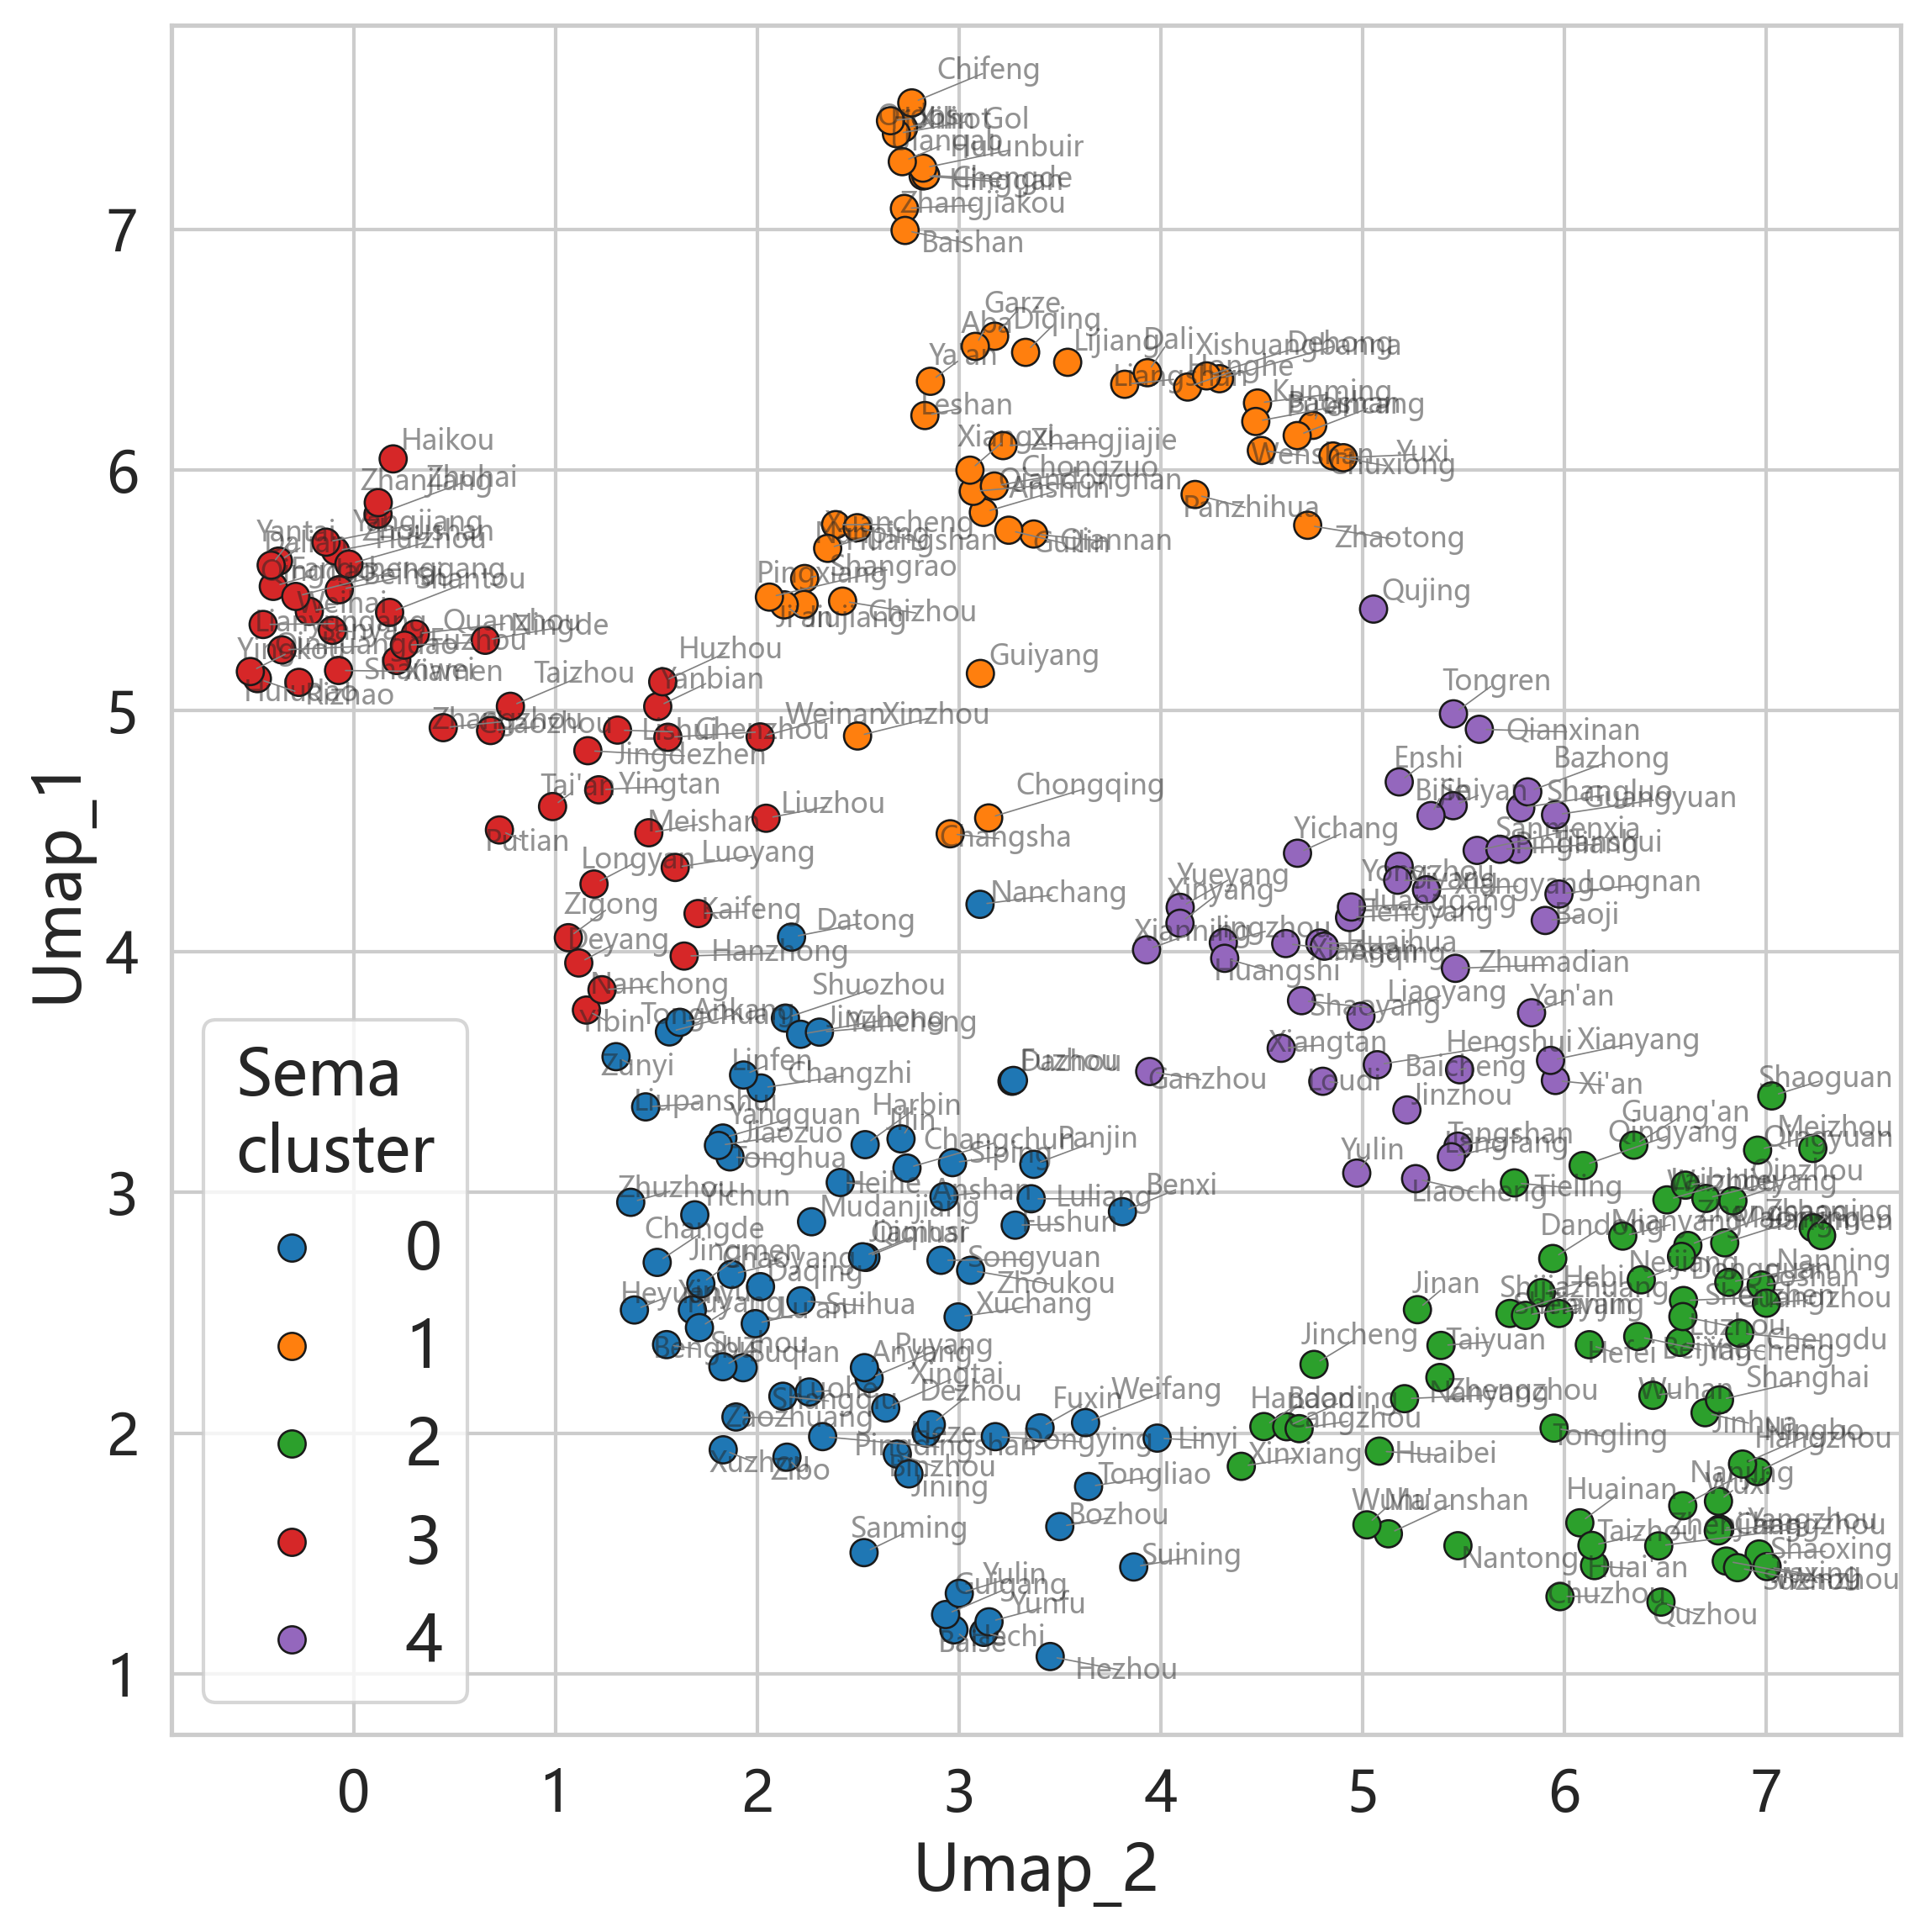

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from adjustText import adjust_text


plt.rcParams.update({
    'font.family': 'Microsoft YaHei',
    'font.size': 18,
    'axes.labelsize': 18,
    'legend.fontsize': 18,
    'legend.title_fontsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
})


X           = time_intensity_df[['umap_1', 'umap_2']].values
city_labels = time_intensity_df['city_en'].values


k_values = np.random.choice(range(5, 6), 1, replace=False)
inits    = np.random.choice(['k-means++', 'random'], 5, replace=True)

results = []
for k, init in zip(k_values, inits):
    km      = KMeans(n_clusters=k, init=init, n_init=10, random_state=42)
    labels  = km.fit_predict(X)
    score   = silhouette_score(X, labels)
    results.append({'k': k, 'init': init, 'score': score,
                    'model': km, 'labels': labels})

best = max(results, key=lambda d: d['score'])


df_plot = pd.DataFrame(X, columns=['umap_1', 'umap_2'])
df_plot['cluster'] = best['labels']
df_plot['city']    = city_labels


plt.figure(figsize=(8, 8), dpi=300)
sns.scatterplot(data=df_plot,
                x='umap_2', y='umap_1',
                hue='cluster', palette='tab10',
                s=60, edgecolor='k', legend='full')

texts = []
for _, row in df_plot.iterrows():
    texts.append(
        plt.text(row['umap_2'], row['umap_1'],
                 row['city'], fontsize=8, alpha=0.5)
    )


adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.4),
            expand_points=(1.2, 1.2),
            expand_text=(1.2, 1.2),
            force_text=0.5, force_points=0.2)

print(f'Best KMeans (k={best["k"]}, init={best["init"]}, '
      f'silhouette={best["score"]:.2f})')

plt.xlabel('Umap_2')
plt.ylabel('Umap_1')
plt.legend(title='Sema\ncluster')
plt.tight_layout()

# plt.savefig('plot/jieou/sema.png', bbox_inches='tight', dpi=300)

plt.show()


In [11]:
import geopandas as gpd
import pandas as pd



city_geom = gdf[['city', 'geometry']].copy()
merged = time_intensity_df.merge(city_geom, on='city', how='left')
gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs=gdf.crs)
gdf['sema_cluster'] = df_plot['cluster']
gdf

,city,intensity,umap_1,umap_2,time,log_intensity,quartile,color,city_en,geometry,sema_cluster
0,梅州,13170,3.175451,6.958565,132,4.119586,Q2,#2ca02c,Meizhou,"POLYGON Z ((115.88406 24.92896 0, 115.89031 24...",2
1,吕梁,17040,2.973684,3.357782,120,4.231470,Q2,#2ca02c,Luliang,"POLYGON Z ((111.20539 38.72164 0, 111.20739 38...",0
2,舟山,31566,5.663746,-0.090759,102,4.499220,Q3,#ff7f0e,Zhoushan,"MULTIPOLYGON Z (((122.25205 29.69094 0, 122.23...",3
3,朝阳,7912,2.659808,1.873272,101,3.898286,Q1,#1f77b4,Chaoyang,"POLYGON Z ((119.6002 42.27468 0, 119.60812 42....",0
4,广安,6443,3.196313,6.344944,119,3.809088,Q1,#1f77b4,Guang'an,"MULTIPOLYGON Z (((107.26394 30.38628 0, 107.27...",2
...,...,...,...,...,...,...,...,...,...,...,...
271,陇南,7059,4.239348,5.974148,111,3.848743,Q1,#1f77b4,Longnan,"POLYGON Z ((105.24292 34.52701 0, 105.2453 34....",4
272,保山,11598,6.201652,4.471026,119,4.064383,Q2,#2ca02c,Baoshan,"POLYGON Z ((98.7239 25.82049 0, 98.7109 25.806...",1
273,遂宁,7474,1.444519,3.866109,117,3.873553,Q1,#1f77b4,Suining,"MULTIPOLYGON Z (((105.90684 30.48512 0, 105.91...",0
274,合肥,167171,2.367577,6.124521,117,5.223161,Q4,#d62728,Hefei,"POLYGON Z ((117.19746 32.52641 0, 117.20584 32...",2


In [12]:
gdf.to_file('data/result2/result.shp', encoding='utf-8')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21844\2482651255.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('data/result2/result.shp', encoding='utf-8')
d:\Anaconda\envs\flood_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'log_intensity' to 'log_intens'
  ogr_write(
d:\Anaconda\envs\flood_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'sema_cluster' to 'sema_clust'
  ogr_write(


C:\Users\Admin\AppData\Local\Temp\ipykernel_21844\1641857107.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_21844\1641857107.py:105: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  p_val = float(row['p-adj'])


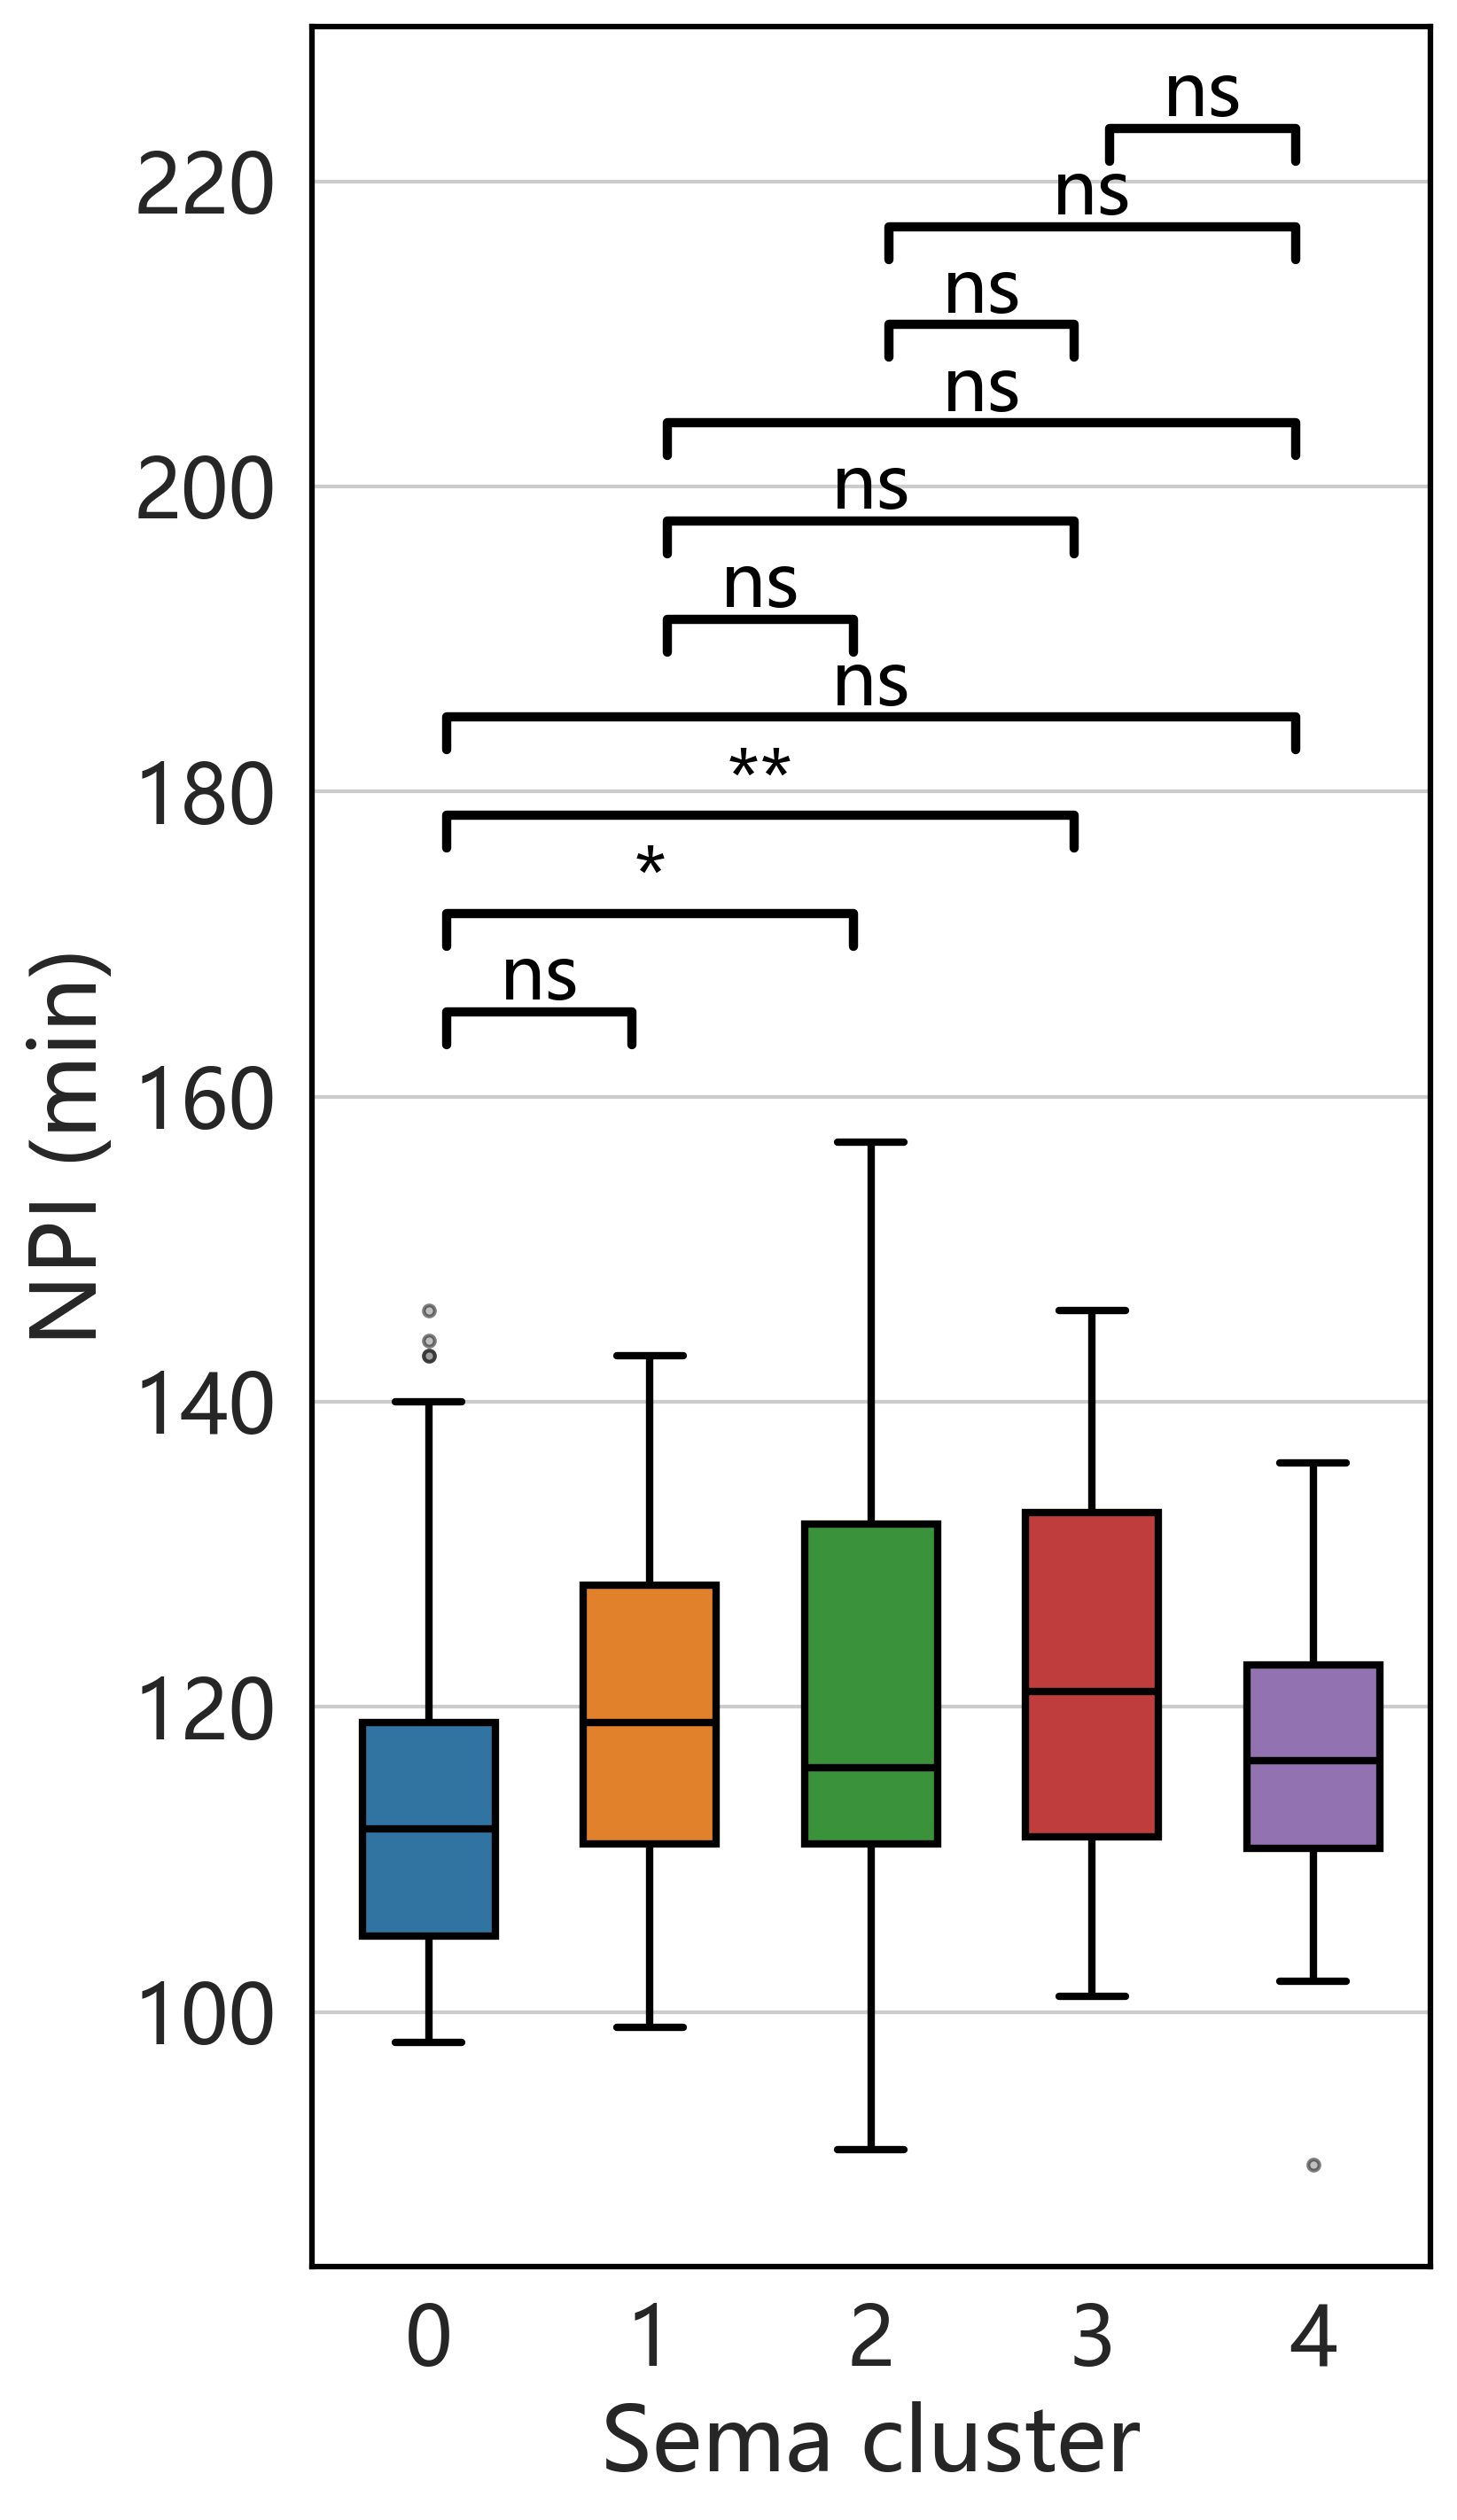

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from itertools import combinations


df = gdf.copy()
plt.rcParams.update({
    'font.size': 30,
    'font.family': 'Microsoft YaHei'
})
sns.set_theme(style="whitegrid")

sns.set_theme(
    context='notebook',
    style="whitegrid",
    font='Microsoft YaHei',
    rc={
        'font.size': 24,
        'axes.titlesize': 24,
        'axes.labelsize': 24,
        'xtick.labelsize': 22,
        'ytick.labelsize': 22,
    }
)

clusters = sorted(df['sema_cluster'].unique())
n_clusters = len(clusters)
palette = sns.color_palette('tab10', n_clusters)


fig, ax = plt.subplots(figsize=(6, 10), dpi=300)

sns.boxplot(
    x='sema_cluster',
    y='time',
    data=df,
    order=clusters,
    palette=palette,
    width=0.6,
    ax=ax,
    linewidth=2,
    boxprops={'edgecolor': 'black'},
    whiskerprops={'color': 'black', 'linewidth': 2},
    capprops={'color': 'black', 'linewidth': 2},
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': 'gray',
                'alpha': 0.5, 'markeredgecolor': 'black'}
)

ax.set_xlabel('Sema cluster')
ax.set_ylabel('NPI (min)')
ax.set_title('')


for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)


from statsmodels.stats.multicomp import pairwise_tukeyhsd


tukey_result = pairwise_tukeyhsd(
    endog=df['time'],
    groups=df['sema_cluster'],
    alpha=0.05
)


tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:],
                        columns=tukey_result._results_table.data[0])


max_y = df['time'].max()
min_y = df['time'].min()
step = (max_y - min_y) * 0.08


pairs = list(combinations(range(len(clusters)), 2))


significance_map = {3: '***', 2: '**', 1: '*', 0: 'ns'}

def significance_label(p):
    if p < 0.001:
        return significance_map[3]
    elif p < 0.01:
        return significance_map[2]
    elif p < 0.05:
        return significance_map[1]
    return significance_map[0]


for k, (i, j) in enumerate(pairs):
    label_i = clusters[i]
    label_j = clusters[j]

    cond1 = (tukey_df['group1'] == label_i) & (tukey_df['group2'] == label_j)
    cond2 = (tukey_df['group1'] == label_j) & (tukey_df['group2'] == label_i)
    row = tukey_df[cond1 | cond2]

    if not row.empty:
        p_val = float(row['p-adj'])

        base_y = max_y + step * (k + 1) * 1.2
        line_y = base_y + step * 0.4
        text_y = line_y + step * 0.2

        x1, x2 = i, j

        ax.plot([x1 + 0.08, x1 + 0.08, x2 - 0.08, x2 - 0.08],
                [base_y, line_y, line_y, base_y],
                lw=2.5, color='black')

        ax.text((x1 + x2) / 2, text_y - 1.5, significance_label(p_val),fontsize=20,
                ha='center', va='bottom', color='black')


plt.tight_layout()
# plt.savefig('plot/jieou/sema_cluster_boxplot.jpg', dpi=300)
plt.show()


In [14]:
from scipy.stats import f_oneway

grouped_values = [group['time'].values for name, group in df.groupby('sema_cluster')]
f_stat, p_val = f_oneway(*grouped_values)
print(f"ANOVA F = {f_stat:.4f}, p = {p_val:.4e}")


ANOVA F = 4.2372, p = 2.4165e-03


In [15]:
gdf.to_file(r'data/result2/result.shp')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21844\3364526186.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(r'data/result2/result.shp')
d:\Anaconda\envs\flood_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'log_intensity' to 'log_intens'
  ogr_write(
d:\Anaconda\envs\flood_env\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'sema_cluster' to 'sema_clust'
  ogr_write(
